# Live Coding Kecerdasan Artifisial Lanjut


---
## Bab 10. Hierarchical Clustering


Nama: Hassan Nashrallah

NIM: 245150200111025

## **Hierarchical Clustering**

Hierarchical clustering adalah pendekatan dalam analisis data yang bertujuan mengelompokkan objek-objek berdasarkan kemiripan mereka, dengan cara yang membentuk struktur bertingkat seperti pohon. Pendekatan ini memungkinkan kita melihat hubungan antar kelompok secara lebih mendalam dan bertahap, dari yang paling umum hingga yang paling spesifik.

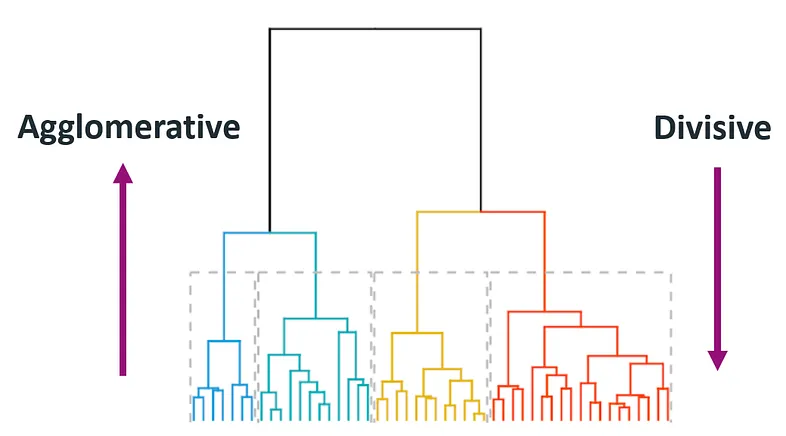

### **Ciri-ciri Utama:**

- **Struktur Bertingkat:**  Proses ini menyusun kelompok secara bertahap, mulai dari tiap objek berdiri sendiri hingga akhirnya tergabung ke dalam kelompok-kelompok yang lebih besar.
- **Pohon Relasi (Dendrogram)**: Representasi visual yang menunjukkan bagaimana objek-objek atau kelompok saling berkaitan pada berbagai tingkat kemiripan.
- **Pendekatan Umum**:
  - Dari bawah ke atas (agglomerative): Menggabungkan objek-objek yang paling mirip secara bertahap.
  - Dari atas ke bawah (divisive): Memisahkan satu kelompok besar menjadi bagian-bagian yang lebih kecil secara bertahap.

- **Contoh Penggunaan:**
  - **Biologi:** Mengelompokkan spesies atau gen berdasarkan kedekatan sifat.
  - **Bisnis:** Menyusun segmen pelanggan berdasarkan karakteristik perilaku.
  - **Analisis Sosial:** Menelusuri struktur hubungan dalam suatu jaringan sosial.

### **Gambaran Cara Kerja (Agglomerative):**

1. **Inisialisasi (Pembentukan Awal):**
Setiap objek dianggap sebagai kelompoknya sendiri. Belum ada penggabungan antar objek.

2. **Penggabungan Awal (Menyatukan yang Paling Mirip):**
Dua objek atau kelompok yang paling mirip digabungkan menjadi satu kelompok baru.

3. **Penggabungan Bertahap (Pembangunan Hirarki):**
Proses penggabungan dilanjutkan dengan mencari pasangan kelompok yang paling mirip berikutnya, dan seterusnya, hingga seluruh objek tergabung dalam satu kelompok besar.

4. **Visualisasi (Penyusunan Dendrogram):**
Seluruh proses penggabungan divisualisasikan dalam bentuk pohon (dendrogram), yang memperlihatkan urutan dan tingkat kemiripan antar kelompok dalam struktur bertingkat.

Hierarchical clustering membantu kita memahami struktur dalam data dengan cara yang natural dan bertingkat, sehingga cocok digunakan saat kita ingin mengeksplorasi pola atau hubungan tersembunyi secara bertahap.



---

## **Separation of Concerns (SoC)**

**Separation of Concerns (SoC)** adalah prinsip fundamental dalam rekayasa perangkat lunak yang menekankan pemisahan tanggung jawab dalam sistem menjadi bagian-bagian yang saling independen dan kohesif. Setiap komponen atau modul bertanggung jawab atas satu aspek spesifik dari sistem, sehingga mencegah terjadinya tumpang tindih tanggung jawab. Tujuan utama dari SoC adalah mengurangi kompleksitas sistem, meningkatkan fleksibilitas arsitektur, serta memperbaiki aspek pemeliharaan dan pengujian.

### **Aspek Teoritis Utama:**

* **Modularisasi:** Sistem dipecah menjadi modul-modul dengan tanggung jawab tunggal (single responsibility), sesuai dengan prinsip *modular design*. Ini memfasilitasi pengembangan terpisah dan integrasi yang lebih terkontrol.

* **Enkapsulasi:** Setiap modul menyembunyikan detail implementasi internal dan hanya mengekspos antarmuka publik yang relevan, mendukung prinsip *information hiding* seperti yang dikemukakan oleh David Parnas.

* **Abstraksi:** Penggunaan lapisan atau antarmuka untuk memisahkan antarmuka pengguna dari logika bisnis atau data, memungkinkan perubahan di satu bagian tanpa memengaruhi bagian lain.

* **Kohesi dan Keterkaitan (Cohesion & Coupling):** SoC bertujuan mencapai kohesi tinggi (fokus tanggung jawab dalam satu modul) dan keterkaitan rendah (minim ketergantungan antar modul), dua metrik penting dalam evaluasi kualitas desain perangkat lunak.

### **Keuntungan dari Separation of Concerns:**

* **Reduksi Kompleksitas:** Sistem menjadi lebih mudah dipahami karena setiap bagian memiliki tujuan dan fungsi yang jelas.
* **Pemeliharaan yang Lebih Mudah:** Perubahan atau perbaikan dapat dilakukan di satu area tanpa berdampak luas terhadap keseluruhan sistem.
* **Pengujian Terfokus (Isolated Testing):** Modul dapat diuji secara individual, mendukung pendekatan *unit testing* dan pengembangan berbasis test (TDD).
* **Skalabilitas Arsitektur:** SoC memungkinkan pengembangan sistem yang dapat tumbuh secara modular sesuai kebutuhan fungsional maupun non-fungsional.
* **Reusabilitas:** Komponen yang dirancang dengan tanggung jawab tunggal dan batasan jelas lebih mudah untuk digunakan ulang dalam konteks proyek lain.

### **Penerapan Praktis:**

* **Model-View-Controller (MVC):** Arsitektur yang memisahkan data (Model), antarmuka pengguna (View), dan logika kontrol (Controller), memungkinkan pengembangan paralel dan pengujian terpisah.

* **Arsitektur Berlapis (Layered Architecture):** Sistem dibagi menjadi lapisan-lapisan fungsional seperti presentasi, logika bisnis, dan akses data untuk menjaga pemisahan tanggung jawab.

* **Microservices:** Sistem dibagi menjadi layanan-layanan independen yang masing-masing mengelola satu domain fungsional spesifik, dengan komunikasi terstandarisasi (biasanya melalui API).

---



### Inisialisasi Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist, squareform

### Load dan Persiapan Data

In [2]:
def load_and_prepare_data(n_samples=150, centers=3, cluster_std=1.0, random_state=42):
    X, y = make_blobs(n_samples=n_samples, centers=centers, cluster_std=cluster_std, random_state=random_state)
    return X, y

In [3]:
# scaler lihat di library
def standardize_data(X):
    scaler = StandardScaler()
    return scaler.fit_transform(X)

In [4]:
def apply_pca(X_scaled, n_components=2):
    pca = PCA(n_components=n_components)
    return pca.fit_transform(X_scaled)

### Visualisasi

In [5]:
def plot_original_data(X_pca, y):
    plt.figure(figsize=(6, 4))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Set1', edgecolor='k')
    plt.title("Visualisasi PCA Dataset Blob (Label Asli)")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)
    plt.show()

### Agglomerative Clustering

In [6]:
def plot_dendrogram(X_scaled, method):
    Z = linkage(X_scaled, method=method)
    coph_corr, _ = cophenet(Z, pdist(X_scaled))
    print(f"Cophenetic Correlation Coefficient ({method}): {coph_corr:.4f}")

    plt.figure(figsize=(10, 5))
    dendrogram(Z,
                truncate_mode='lastp',
                p=30,
                leaf_rotation=90.,
                leaf_font_size=10.,
                show_contracted=True)
    plt.title(f"Agglomerative Clustering - {method.capitalize()} Linkage")
    plt.xlabel("Sample Index")
    plt.ylabel("Distance")
    plt.grid(True)
    plt.show()
    return Z

In [7]:
def evaluate_clusters(Z, y, X_pca, method, max_clusters=10):
    labels = fcluster(Z, max_clusters, criterion='maxclust')
    ari = adjusted_rand_score(y, labels)
    print(f"Adjusted Rand Index ({method}): {ari:.4f}")

    plt.figure(figsize=(6, 4))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='rainbow', edgecolor='k')
    plt.title(f"Hasil Cluster - {method.capitalize()} Linkage")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)
    plt.show()

### Matriks Jarak

In [8]:
def show_distance_matrix(X_scaled):
    distances = pdist(X_scaled)
    dist_matrix = squareform(distances)
    print("\nContoh Matriks Jarak (5x5):")
    print(pd.DataFrame(dist_matrix[:5, :5]))

### Metode Elbow

In [9]:
def elbow_method(Z, X_scaled, max_k=10):
    distortions = []
    K = range(1, max_k + 1)
    for k in K:
        labels = fcluster(Z, k, criterion='maxclust')
        total_dist = 0
        for label in np.unique(labels):
            cluster_points = X_scaled[labels == label]
            centroid = cluster_points.mean(axis=0)
            dist = np.sum((cluster_points - centroid) ** 2)
            total_dist += dist
        distortions.append(total_dist)

    plt.figure(figsize=(6, 4))
    plt.plot(K, distortions, 'bo-')
    plt.xlabel("Jumlah Klaster (k)")
    plt.ylabel("Total Within-Cluster Sum of Squares")
    plt.title("Metode Elbow untuk Hierarchical Clustering")
    plt.grid(True)
    plt.axvline(x=3, color='red', linestyle='--', label='k = 3')
    plt.legend()
    plt.show()

    best_k = 3  
    return best_k

### Main

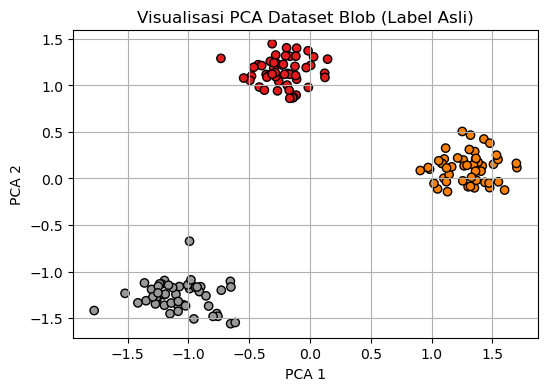


Contoh Matriks Jarak (5x5):
          0         1         2         3         4
0  0.000000  0.331882  2.889815  2.291161  2.709455
1  0.331882  0.000000  2.568022  2.292945  2.387616
2  2.889815  2.568022  0.000000  3.112755  0.180411
3  2.291161  2.292945  3.112755  0.000000  2.990251
4  2.709455  2.387616  0.180411  2.990251  0.000000

[Clustering - ward]
Cophenetic Correlation Coefficient (ward): 0.9764


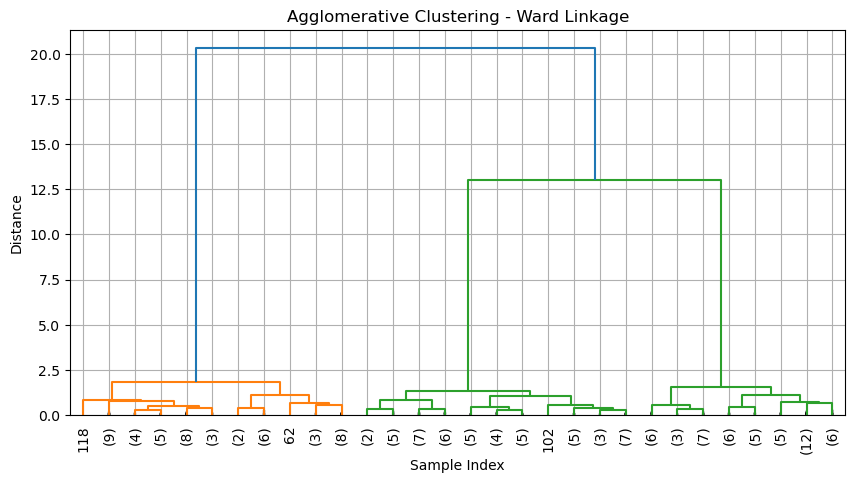

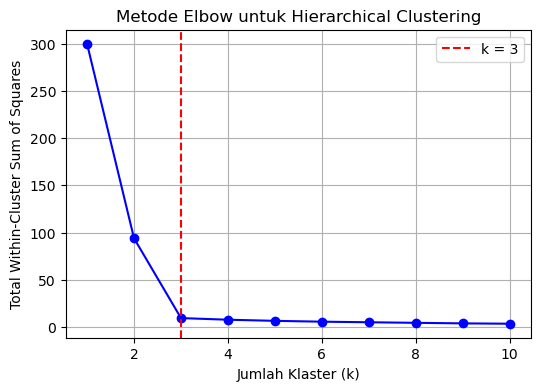

Adjusted Rand Index (ward): 1.0000


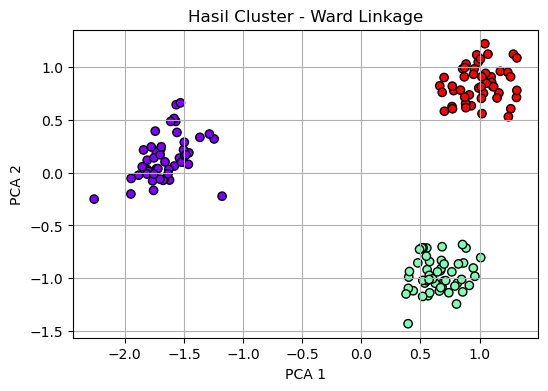

In [10]:
def main():
    X, y = load_and_prepare_data()
    X_scaled = standardize_data(X)
    X_pca = apply_pca(X_scaled)

    plot_original_data(X_scaled, y)
    show_distance_matrix(X_scaled)

    linkage_methods = ['ward']
    for method in linkage_methods:
        print(f"\n[Clustering - {method}]")
        Z = plot_dendrogram(X_scaled, method)
        best_k = elbow_method(Z, X_scaled)
        evaluate_clusters(Z, y, X_pca, method, best_k)
if __name__ == "__main__":
    main()

### Pertanyaan

Jelaskan apa itu hierarchical clustering menurut pemahaman kalian dan berikan contohnya (semakin unik semakin bagus)!

Hierarchical clustering adalah metode clustering yang mengelompokkan data dalam bentuk hierarki atau tingkatan, berdasarkan tingkat kemiripan atau jarak antar data. Disebut hierarchical karena hasil akhirnya berbentuk hirarki atau tingkatan, yang bernama dendrogram. menggabungkan data yang paling mirip terlebih dahulu, lalu secara bertahap akan membentuk cluster yang lebih besar.

Hierarchical Clustering dapat digunakan untuk membangun algoritma sistem rekomendasi. Dalam hal ini, Hierarchical Clustering akan mengelompokkan produk yang memiliki kemiripan ke dalam beberapa kelompok. Setelah itu, sistem dapat merekomendasikan produk lain dari cluster yang sama atau berdekatan. Dengan demikian, ketika pengguna membeli atau melihat suatu produk, sistem dapat merekomendasikan produk lain yang berada dalam kelompok serupa. Sebagai contoh, pengguna yang membeli laptop gaming akan mendapatkan rekomendasi mouse gaming, keyboard mekanik, dan headset gaming karena produk-produk tersebut memiliki hubungan yang dekat dalam cluster yang sama.